
# Notebook 00 — Exploration des données (EDA)

**Copilote Financier — Groupe Angelotti | Mémoire M2 MIASHS**

Ce notebook applique la démarche du cours *EDA for Data Science*
(G. Miguiama Bamba, janvier 2026) à nos données de gestion immobilière :
les sections suivent sa checklist (comprendre le problème → qualité →
univarié → bivarié → ingénierie → outliers → manquants → notions avancées
→ synthèse), et nous en reprenons les conventions de code (p. 3-8).

Concepts mobilisés ici : **distribution normale, z-score, corrélation de
Pearson, entropie**, transformation log, détection d'outliers par IQR,
fuite de cible, déséquilibre de classes.


In [1]:
# --- Amorçage : exécution locale ou Google Colab ---
import pathlib, subprocess, sys

racine = pathlib.Path.cwd()
while not (racine / "src" / "nettoyage.py").exists() and racine != racine.parent:
    racine = racine.parent
if not (racine / "src" / "nettoyage.py").exists():  # environnement Colab vierge
    subprocess.run(["git", "clone", "-b", "claude/copilote-financier-angelotti-72c614",
                    "https://github.com/yzasmin/MemoireM2S2.git"], check=True)
    racine = pathlib.Path.cwd() / "MemoireM2S2"
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r",
                    str(racine / "requirements.txt")], check=True)

sys.path.insert(0, str(racine / "src"))
import base_sql

if not base_sql.DB.exists():  # reconstruit data/copilote.db depuis donnéebrut/
    base_sql.construire_base()
DB = base_sql.DB
print("Base prête :", DB)


Base prête : /home/user/MemoireM2S2/data/copilote.db



## 1. Comprendre le problème *(cours EDA, p. 3)*

Le cours recommande de formaliser le problème dans un dictionnaire
`problem` **avant** de regarder les données : objectif métier, cible,
métrique, contraintes. Nous le faisons pour les trois axes du copilote.


In [2]:

problemes = {
    "axe_A_risque_marge": {
        "type": "régression puis classification",
        "target": "taux de variation de la marge (budget -> réalisé) ; classe 'à risque'",
        "metric": "R2 / MSE (régression), F1 (classification, classes déséquilibrées)",
        "constraints": ["n ~ 150 opérations exploitables -> modèles régularisés",
                        "interprétabilité exigée par la direction financière"],
    },
    "axe_B_ecoulement": {
        "type": "régression sur données répétées + série temporelle",
        "target": "nb de réservations par opération x mois",
        "metric": "MSE hors-échantillon, AICc (choix de modèle ARIMAX)",
        "constraints": ["effet opération != effet conjoncture (modèle à effets aléatoires)",
                        "scénarios de taux 2026 exigés"],
    },
    "axe_C_prix": {
        "type": "régression hédonique + optimisation sous contrainte",
        "target": "prix TTC au m² d'un lot",
        "metric": "R2, RMSE ; revenu attendu (optimisation)",
        "constraints": ["recommandations explicables lot par lot"],
    },
}
for k, v in problemes.items():
    print(f"— {k}: cible = {v['target']}")


— axe_A_risque_marge: cible = taux de variation de la marge (budget -> réalisé) ; classe 'à risque'
— axe_B_ecoulement: cible = nb de réservations par opération x mois
— axe_C_prix: cible = prix TTC au m² d'un lot



## 2. Chargement des données *(cours EDA, p. 3 : `head`, `shape`, `info`)*

Les données propres viennent de la base SQLite construite par
`src/base_sql.py` (voir `docs/02_dictionnaire_donnees.md`). On charge les
7 tables et la vue de marge.


In [3]:

import sqlite3
import numpy as np
import pandas as pd

import theme_viz
theme_viz.appliquer()

con = sqlite3.connect(DB)
tables = {t: pd.read_sql(f'SELECT * FROM "{t}"', con)
          for t in ["operations", "budget", "lots", "ventes", "desistements",
                    "communes", "conjoncture", "v_marge_operation"]}
for t, df in tables.items():
    print(f"{t:20s} {df.shape[0]:6d} lignes x {df.shape[1]:3d} colonnes")
lots, ventes, marge = tables["lots"], tables["ventes"], tables["v_marge_operation"]


operations              267 lignes x  13 colonnes
budget                64788 lignes x  10 colonnes
lots                  14123 lignes x  22 colonnes
ventes                14428 lignes x  22 colonnes
desistements           2164 lignes x  18 colonnes
communes                 90 lignes x  10 colonnes
conjoncture             138 lignes x   3 colonnes
v_marge_operation       267 lignes x  12 colonnes


In [4]:

lots.head(3)


,id_operation,numero_lot,nature_lot_source,type_lot,type_produit,type_ouvrage,principal_secondaire,surface,surface_habitable,surface_terrain,...,exposition,etage,statut_lot,prix_budget_ttc,prix_lancement_ttc,prix_vente_ttc,remise_ttc,taux_tva,nature_lot,prix_m2_ttc
0,29,2-0001,Appartement,2 Pièces,SOCIAL,Collectif social,Principal,42.0,42.0,0.0,...,NaN,0,Désisté,102522.0,0.0,1999172.250,0.0,0.055,Appartement,47599.339286
1,29,1-0001,Appartement,4 Pièces,SOCIAL,Collectif social,Principal,76.0,76.0,0.0,...,NaN,0,Désisté,158966.0,0.0,4656173.925,0.0,0.055,Appartement,61265.446382
2,29,3-0001,Autres activités,1 Pièce,ACTIVITE,Activité,Principal,166.0,0.0,0.0,...,NaN,0,Désisté,480000.0,479999.0,38470.575,0.0,0.055,Autre,231.750452



## 3. Vérification de la qualité *(cours EDA, p. 3-4)*

Valeurs manquantes (`isnull().mean()`), doublons (`duplicated().sum()`),
types. Les gros problèmes de qualité (fichier des lots limité aux
désistements, libellés hétérogènes, valeurs sentinelles à 0) ont été
identifiés en amont et corrigés dans `src/nettoyage.py` ; on vérifie ici
le résultat.


In [5]:

qualite = []
for t, df in tables.items():
    qualite.append({
        "table": t,
        "doublons": int(df.duplicated().sum()),
        "% manquant (max colonne)": round(100 * df.isnull().mean().max(), 1),
        "colonnes 100% remplies": int((df.notnull().all()).sum()),
    })
pd.DataFrame(qualite)


,table,doublons,% manquant (max colonne),colonnes 100% remplies
0,operations,0,0.7,10
1,budget,0,0.0,10
2,lots,0,79.1,5
3,ventes,0,100.0,6
4,desistements,0,95.7,4
5,communes,0,0.0,10
6,conjoncture,0,0.0,3
7,v_marge_operation,0,0.0,12


In [6]:

# Ratio de manquants par colonne, convention du cours (p. 4) :
# missing_ratio = (df.isnull().mean() * 100)
missing_ratio = (lots.isnull().mean() * 100).sort_values(ascending=False)
print("Colonnes de `lots` les plus lacunaires (%) :")
print(missing_ratio.head(8).round(1).to_string())
print("\nLecture : l'étage, l'exposition et les surfaces annexes ne sont"
      "\nrenseignés que pour les appartements ; les prix manquants sont les"
      "\nanciennes valeurs sentinelles 0 (stationnements non déployés).")


Colonnes de `lots` les plus lacunaires (%) :
exposition            79.1
prix_m2_ttc           39.3
surface               38.7
etage                 17.1
remise_ttc            14.3
prix_vente_ttc        13.2
type_produit           0.5
prix_lancement_ttc     0.0

Lecture : l'étage, l'exposition et les surfaces annexes ne sont
renseignés que pour les appartements ; les prix manquants sont les
anciennes valeurs sentinelles 0 (stationnements non déployés).



## 4. Analyse univariée *(cours EDA, p. 4)* — distribution normale et z-score

Le cours recommande `describe()` enrichi de l'asymétrie (`skew`) et de
l'aplatissement (`kurtosis`), puis des histogrammes. Nous examinons la
variable centrale de l'axe C : le **prix TTC au m²** des lots principaux.

Le z-score est cité par le cours comme outil de détection d'outliers
(p. 4 et 6) sans formule ; nous utilisons la définition classique
$z_i = \dfrac{x_i - \bar{x}}{s}$ (Azencott, *Introduction au Machine
Learning*, référence des cours de classification) : si $X$ suit une
**distribution normale** $\mathcal{N}(\mu, \sigma^2)$, alors 99,7 % des
observations vérifient $|z| \leq 3$.


In [7]:

appts = lots.query("nature_lot == 'Appartement' and prix_m2_ttc > 0").copy()
resume = appts["prix_m2_ttc"].describe().to_frame().T
resume["skew"] = appts["prix_m2_ttc"].skew()
resume["kurtosis"] = appts["prix_m2_ttc"].kurtosis()
resume.round(1)


,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
prix_m2_ttc,5137.0,2995.7,1433.0,1240.4,2119.3,2917.5,3674.4,61265.4,19.2,713.6


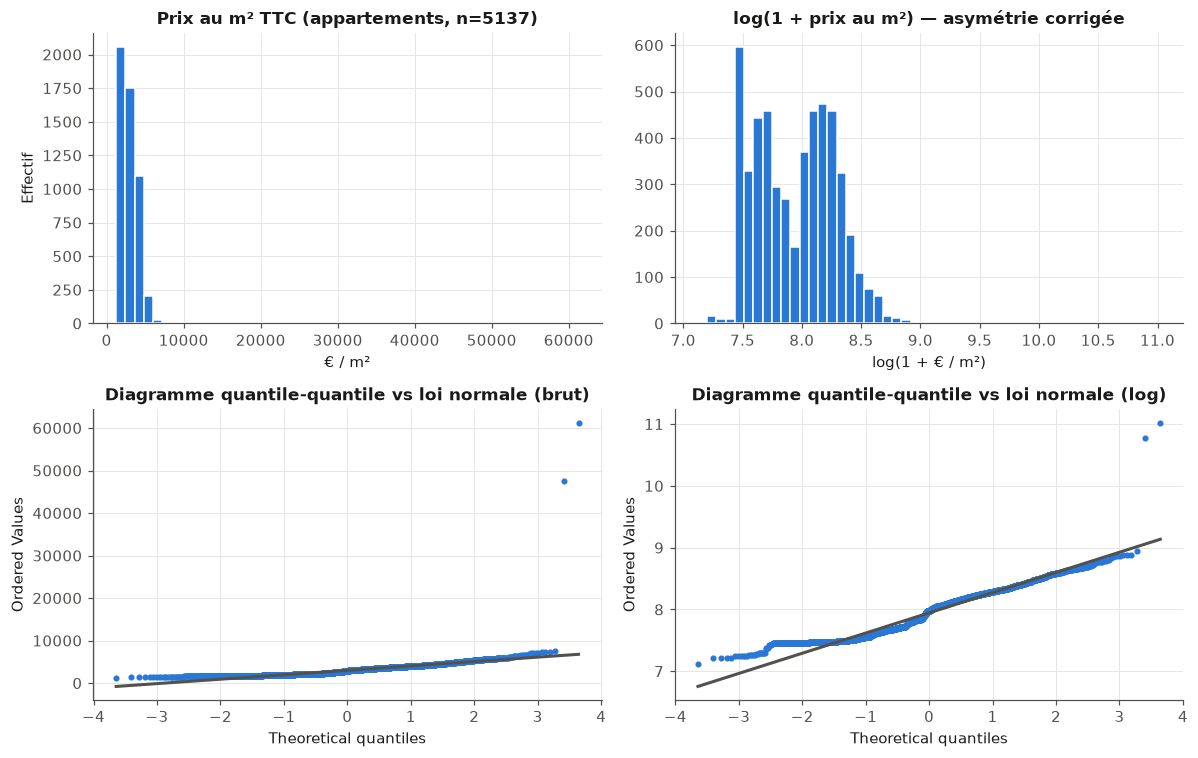

Asymétrie brut : 19.20  |  log : 0.39
Outliers |z| > 3 : brut 3 lots, log 2 lots


In [8]:

import matplotlib.pyplot as plt
from scipy import stats

x = appts["prix_m2_ttc"].dropna()
z = (x - x.mean()) / x.std()          # z-score : z_i = (x_i - x̄)/s
logx = np.log1p(x)                    # transformation log du cours (p. 6)
zlog = (logx - logx.mean()) / logx.std()

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
axes[0, 0].hist(x, bins=50, color=theme_viz.SERIES[0], edgecolor="white")
axes[0, 0].set_title(f"Prix au m² TTC (appartements, n={len(x)})")
axes[0, 0].set_xlabel("€ / m²"); axes[0, 0].set_ylabel("Effectif")

axes[0, 1].hist(logx, bins=50, color=theme_viz.SERIES[0], edgecolor="white")
axes[0, 1].set_title("log(1 + prix au m²) — asymétrie corrigée")
axes[0, 1].set_xlabel("log(1 + € / m²)")

stats.probplot(x, dist="norm", plot=axes[1, 0])
axes[1, 0].get_lines()[0].set(color=theme_viz.SERIES[0], markersize=3)
axes[1, 0].get_lines()[1].set(color=theme_viz.ENCRE_2)
axes[1, 0].set_title("Diagramme quantile-quantile vs loi normale (brut)")

stats.probplot(logx, dist="norm", plot=axes[1, 1])
axes[1, 1].get_lines()[0].set(color=theme_viz.SERIES[0], markersize=3)
axes[1, 1].get_lines()[1].set(color=theme_viz.ENCRE_2)
axes[1, 1].set_title("Diagramme quantile-quantile vs loi normale (log)")
fig.tight_layout()
plt.show()

print(f"Asymétrie brut : {x.skew():.2f}  |  log : {logx.skew():.2f}")
print(f"Outliers |z| > 3 : brut {int((z.abs() > 3).sum())} lots, "
      f"log {int((zlog.abs() > 3).sum())} lots")



**Lecture.** La distribution brute des prix au m² est asymétrique à droite
(quelques lots de standing tirent la queue) : le z-score sur données brutes
sur-détecte les outliers. Après transformation log (recommandée p. 6 du
cours pour les distributions asymétriques), le diagramme quantile-quantile
est presque rectiligne : l'hypothèse de normalité devient tenable, ce qui
justifiera de modéliser le **log-prix** dans le modèle hédonique (notebook
05) — les erreurs y seront plus proches d'un bruit gaussien, cadre implicite
de l'estimation par moindres carrés.


In [9]:

# Détection d'outliers par IQR, convention exacte du cours (p. 6)
col = "prix_m2_ttc"
Q1 = appts[col].quantile(0.25); Q3 = appts[col].quantile(0.75); IQR = Q3 - Q1
mask_out = (appts[col] < Q1 - 1.5 * IQR) | (appts[col] > Q3 + 1.5 * IQR)
print(f"IQR = {IQR:.0f} €/m² ; bornes [{Q1 - 1.5*IQR:.0f}, {Q3 + 1.5*IQR:.0f}]")
print(f"Outliers IQR : {mask_out.sum()} lots ({100*mask_out.mean():.1f} %)")
appts.loc[mask_out, ["id_operation", "type_lot", "surface", "prix_vente_ttc",
                     "prix_m2_ttc"]].sort_values("prix_m2_ttc").tail(5)


IQR = 1555 €/m² ; bornes [-213, 6007]
Outliers IQR : 30 lots (0.6 %)


,id_operation,type_lot,surface,prix_vente_ttc,prix_m2_ttc
12311,47,1 Pièce,21.0,151900.000,7233.333333
10804,47,1 Pièce,21.0,151900.000,7233.333333
8945,35,4 Pièces,94.0,719000.000,7648.936170
0,29,2 Pièces,42.0,1999172.250,47599.339286
1,29,4 Pièces,76.0,4656173.925,61265.446382



## 5. Analyse bivariée *(cours EDA, p. 5)* — corrélation de Pearson

Le cours opérationnalise la corrélation par `df.corr()` (Pearson par
défaut de pandas). La formule sous-jacente est
$r_{XY} = \dfrac{\sum_i (x_i - \bar{x})(y_i - \bar{y})}
{\sqrt{\sum_i (x_i - \bar{x})^2}\sqrt{\sum_i (y_i - \bar{y})^2}}$.
On l'applique aux variables financières agrégées par opération — celles qui
serviront à l'axe A.


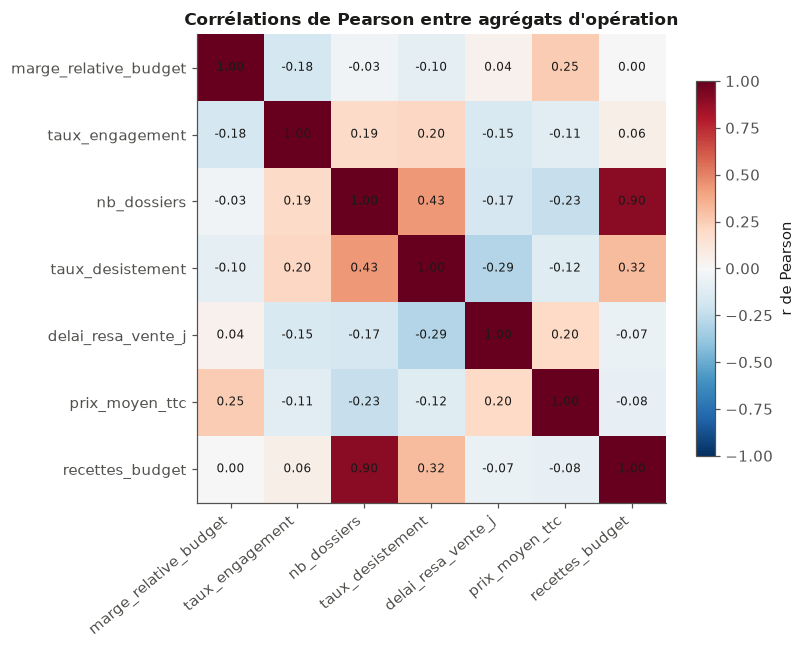

In [10]:

# Agrégats par opération : marge, engagement, écoulement, désistements
ecoul = ventes.groupby("id_operation").agg(
    nb_dossiers=("code_dossier", "count"),
    taux_desistement=("desiste", "mean"),
    delai_resa_vente_j=("delai_resa_vente_j", "median"),
    prix_moyen_ttc=("prix_vente_ttc", "mean"),
)
ops = marge.merge(ecoul, on="id_operation", how="left")
ops["marge_relative_budget"] = ops["marge_budget"] / ops["recettes_budget"]
ops["derive_depenses"] = np.where(
    (ops["taux_engagement"] > 0.3) & (ops["depenses_budget"] > 0),
    ops["depenses_engagees"] / (ops["taux_engagement"] * ops["depenses_budget"]) - 1,
    np.nan)
num = ops[["marge_relative_budget", "taux_engagement", "nb_dossiers",
           "taux_desistement", "delai_resa_vente_j", "prix_moyen_ttc",
           "recettes_budget"]].dropna()
corr = num.corr()          # convention du cours : df.corr()
fig, ax = plt.subplots(figsize=(7.5, 6))
im = ax.imshow(corr, cmap=theme_viz.CMAP_DIV, vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)), corr.columns, rotation=40, ha="right")
ax.set_yticks(range(len(corr)), corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center",
                fontsize=8, color=theme_viz.ENCRE)
ax.set_title("Corrélations de Pearson entre agrégats d'opération")
ax.grid(False)
fig.colorbar(im, shrink=0.8, label="r de Pearson")
plt.tight_layout(); plt.show()



**Lecture.** Trois liens intéressants pour la suite : la marge relative
budgétée est corrélée à la taille de l'opération (recettes) ; le taux de
désistement co-varie avec le délai réservation→vente (les dossiers qui
traînent finissent par tomber) ; le prix moyen n'est pas corrélé
linéairement au taux de désistement — le lien prix→demande passera par le
modèle d'écoulement, pas par une simple corrélation.



## 6. Variables catégorielles et **entropie**

Le cours EDA recommande `value_counts()` et la cardinalité (p. 4). Nous y
ajoutons l'**entropie** au sens du cours d'arbres de décision
(*coursClassif-3ArbresDecision*, slide 16) :
$\mathcal{I}_{\mathcal{E}}(R) = -\sum_k p_k \log_2 p_k$,
qui mesure en bits l'hétérogénéité d'une variable — utile pour repérer les
variables trop concentrées (entropie ≈ 0, peu informatives) ou trop
dispersées (identifiants déguisés).


In [11]:

def entropie(serie: pd.Series) -> float:
    p = serie.value_counts(normalize=True).to_numpy()
    p = p[p > 0]
    return float(-(p * np.log2(p)).sum())      # I_E(R) = -Σ p_k log2 p_k

cats = {"lots": ["nature_lot", "type_produit", "statut_lot", "exposition"],
        "ventes": ["motif_desistement", "vendeur_interne_externe", "qualite_acquereur"],
        "operations": ["agence", "statut", "type_operation"]}
lignes = []
for t, cols in cats.items():
    for c in cols:
        s = tables[t][c].dropna()
        lignes.append({"table": t, "variable": c, "modalités": s.nunique(),
                       "entropie (bits)": round(entropie(s), 2),
                       "max si uniforme": round(np.log2(max(s.nunique(), 1)), 2),
                       "modalité dominante": f"{s.value_counts(normalize=True).iloc[0]:.0%}"})
pd.DataFrame(lignes).sort_values("entropie (bits)", ascending=False)


,table,variable,modalités,entropie (bits),max si uniforme,modalité dominante
7,operations,agence,13,3.27,3.70,19%
3,lots,exposition,8,2.95,3.00,18%
4,ventes,motif_desistement,14,2.22,3.81,42%
1,lots,type_produit,8,2.12,3.00,46%
6,ventes,qualite_acquereur,8,2.00,3.00,39%
0,lots,nature_lot,8,1.95,3.00,36%
2,lots,statut_lot,5,1.46,2.32,65%
8,operations,statut,5,1.43,2.32,62%
9,operations,type_operation,4,1.10,2.00,54%
5,ventes,vendeur_interne_externe,2,0.94,1.00,64%



**Lecture.** `nature_lot` et `agence` portent une information équilibrée
(entropie proche du maximum uniforme). `motif_desistement` est concentré
(42 % « problème de financement / refus de prêt », et davantage en
regroupant les motifs de financement) : ce déséquilibre
guidera la lecture des métriques de l'axe transverse texte (notebook 06),
où le F1 par classe sera préféré à l'exactitude.



## 7. Vue temporelle : réservations, taux d'intérêt, confiance des ménages

Motivation de l'axe B. Deux graphiques empilés à axes distincts (jamais de
double axe) : le rythme mensuel de réservations du groupe, et les deux
exogènes macro qui serviront à l'ARIMAX (notebook 04).


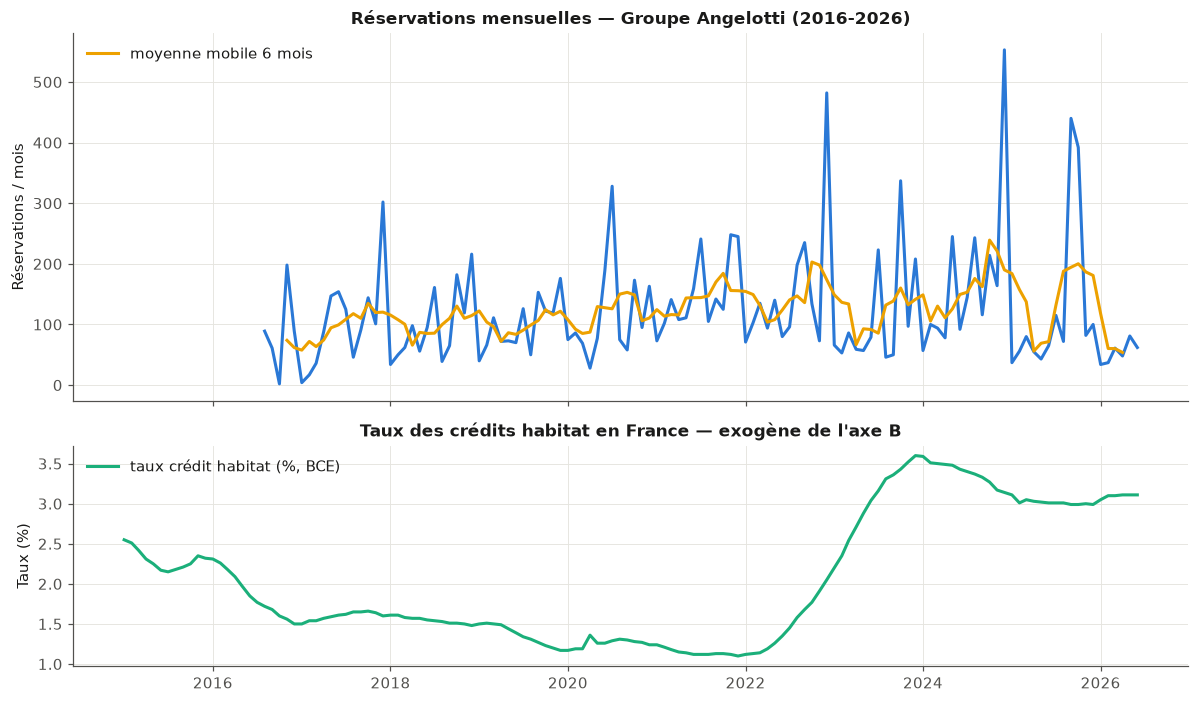

r(réservations, taux crédit)       = +0.07
r(réservations, confiance ménages) = -0.06


In [12]:

resa_m = (ventes.dropna(subset=["date_reservation"])
          .assign(mois=lambda d: pd.to_datetime(d["date_reservation"]).dt.to_period("M"))
          .groupby("mois").size().rename("reservations"))
resa_m.index = resa_m.index.to_timestamp()
conj = tables["conjoncture"].assign(mois=lambda d: pd.to_datetime(d["mois"]))

fig, (a1, a2) = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True,
                             gridspec_kw={"height_ratios": [2, 1.2]})
a1.plot(resa_m.index, resa_m.values, color=theme_viz.SERIES[0])
a1.plot(resa_m.index, resa_m.rolling(6, center=True).mean(),
        color=theme_viz.SERIES[2], label="moyenne mobile 6 mois")
a1.set_title("Réservations mensuelles — Groupe Angelotti (2016-2026)")
a1.set_ylabel("Réservations / mois"); a1.legend(frameon=False)

a2.plot(conj["mois"], conj["taux_credit_habitat"], color=theme_viz.SERIES[1],
        label="taux crédit habitat (%, BCE)")
a2.set_ylabel("Taux (%)")
a2b_vals = conj["confiance_menages"]
a2.plot([], [])  # garde l'ordre des couleurs
a2.legend(frameon=False, loc="upper left")
a2.set_title("Taux des crédits habitat en France — exogène de l'axe B")
fig.tight_layout(); plt.show()

# Corrélation de Pearson réservations <-> taux, sur la période commune
df_corr = resa_m.to_frame().join(conj.set_index("mois"), how="inner")
r_taux = df_corr["reservations"].corr(df_corr["taux_credit_habitat"])
r_conf = df_corr["reservations"].corr(df_corr["confiance_menages"])
print(f"r(réservations, taux crédit)       = {r_taux:+.2f}")
print(f"r(réservations, confiance ménages) = {r_conf:+.2f}")



**Piège de la corrélation brute.** La corrélation de Pearson entre les
réservations mensuelles et le taux d'intérêt est **quasi nulle** — alors
que le lien économique est avéré. Explication : la série brute est **non
stationnaire** et confondue par la taille du portefeuille (le nombre
d'opérations en commercialisation a doublé sur la période, ce qui soutient
le volume de réservations même quand la demande par programme s'effondre).
C'est exactement la mise en garde du cours de séries temporelles contre la
*spurious regression* (*SeriesTemp_ARIMAX*, slide 3). Neutralisons l'effet
portefeuille en passant à l'**intensité** : réservations par opération
active.


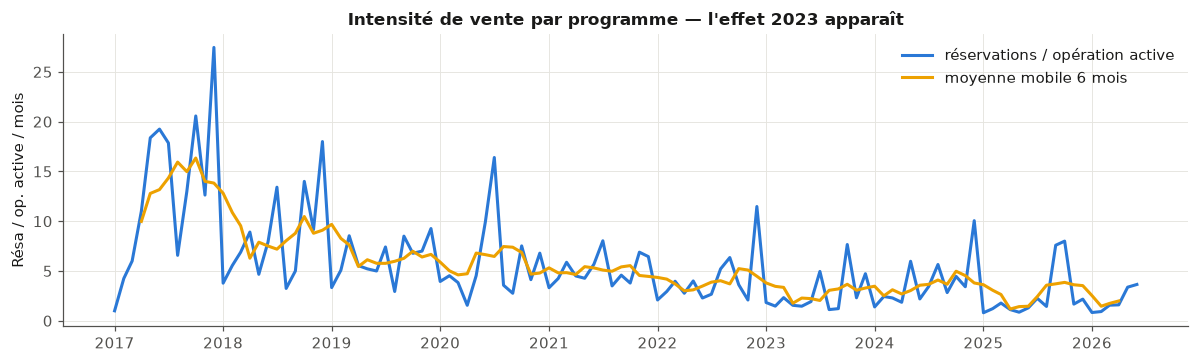

r(intensité, taux crédit)       = -0.34
r(intensité, confiance ménages) = +0.44


In [13]:

# Intensité : réservations par opération active dans le mois
m2 = ventes.dropna(subset=["date_reservation"]).assign(
    mois=lambda d: pd.to_datetime(d["date_reservation"]).dt.to_period("M"))
bornes = m2.groupby("id_operation")["mois"].agg(["min", "max"])
actifs = pd.Series({p: int(((bornes["min"] <= p) & (bornes["max"] >= p)).sum())
                    for p in resa_m.to_period("M").index}, name="ops_actives")
inten = (resa_m.to_period("M") / actifs).rename("resa_par_op").to_frame()
inten.index = inten.index.to_timestamp()
inten = inten.join(conj.set_index("mois"), how="inner")["2017":]

fig, ax = plt.subplots(figsize=(11, 3.4))
ax.plot(inten.index, inten["resa_par_op"], color=theme_viz.SERIES[0],
        label="réservations / opération active")
ax.plot(inten.index, inten["resa_par_op"].rolling(6, center=True).mean(),
        color=theme_viz.SERIES[2], label="moyenne mobile 6 mois")
ax.set_title("Intensité de vente par programme — l'effet 2023 apparaît")
ax.set_ylabel("Résa / op. active / mois"); ax.legend(frameon=False)
plt.tight_layout(); plt.show()

r_i_taux = inten["resa_par_op"].corr(inten["taux_credit_habitat"])
r_i_conf = inten["resa_par_op"].corr(inten["confiance_menages"])
print(f"r(intensité, taux crédit)       = {r_i_taux:+.2f}")
print(f"r(intensité, confiance ménages) = {r_i_conf:+.2f}")



**Lecture.** Une fois l'effet portefeuille neutralisé, le lien macro
apparaît : l'intensité de vente est anticorrélée au taux des crédits
($r \approx -0{,}3$) et corrélée positivement à la confiance des ménages
($r \approx +0{,}4$). Leçon de méthode : sur données séquentielles, une
corrélation de niveau peut masquer (ou fabriquer) une relation — l'axe B
travaillera sur séries transformées (différenciation commune de $y$ et des
$x_k$, *SeriesTemp_ARIMAX* slides 4-5) et contrôlera l'effet opération par
un modèle à effets aléatoires.



## 8. Gestion des valeurs manquantes *(cours EDA, p. 6-7)*

Stratégies retenues, dans l'ordre de préférence du cours (suppression si
faible proportion → imputation simple → imputation prédictive) :

| Variable | % manquant | Stratégie | Justification |
|---|---|---|---|
| `surface`, `prix_vente_ttc` (lots) | ~15-30 % | conserver `NaN`, filtrer par usage | Ce sont d'anciens 0 sentinelles : imputer fausserait les prix au m² |
| `etage`, `exposition` | ~40-60 % | modalité « Inconnu » (one-hot) | Manquant structurel (maisons, terrains, parkings n'ont pas d'étage) |
| `delai_resa_vente_j` | dossiers non actés | non imputé | Censure : traité comme tel dans l'axe B |
| exogènes macro (fin de série) | < 3 mois | report dernière valeur | Documenté au journal ; publication BCE décalée |

Le cours insiste (p. 8) : **le split train/test doit précéder les
transformations apprises** (imputation, standardisation) via `Pipeline` +
`ColumnTransformer` — règle appliquée dans tous les notebooks de
modélisation.



## 9. Notions avancées *(cours EDA, p. 7-8)* : fuite de cible et déséquilibre

Le cours recommande `corrwith` sur la cible pour détecter la **fuite de
cible**. Vérifions pour l'axe A : la cible (variation de marge) ne doit pas
être « prédite » par une variable qui en est une copie comptable.


In [14]:

# Cible provisoire de l'axe A (définition affinée au notebook 03) :
# opérations mûres = engagées à plus de 30 % ou terminées
mures = ops[(ops["taux_engagement"] > 0.3) | (ops["statut"].isin(["Achevé", "Archivé"]))].copy()
mures["marge_actualisee"] = mures["recettes_budget"] - mures["depenses_engagees"]
mures["variation_marge"] = ((mures["marge_actualisee"] - mures["marge_budget"])
                            / mures["marge_budget"].abs())
candidats = mures[["taux_engagement", "nb_dossiers", "taux_desistement",
                   "delai_resa_vente_j", "prix_moyen_ttc", "recettes_budget",
                   "depenses_budget", "depenses_engagees", "marge_budget"]]
fuite = candidats.corrwith(mures["variation_marge"]).sort_values(key=abs, ascending=False)
print("Corrélation à la cible (tri |r| décroissant, convention cours p. 7) :")
print(fuite.round(2).to_string())
print("\n`depenses_engagees` entre dans la DÉFINITION de la cible ->"
      "\nfuite de cible mécanique : à exclure des variables explicatives"
      "\n(on n'utilisera que la STRUCTURE du budget initial, pas le réalisé).")


Corrélation à la cible (tri |r| décroissant, convention cours p. 7) :
delai_resa_vente_j   -0.10
nb_dossiers          -0.08
recettes_budget      -0.06
depenses_budget      -0.06
depenses_engagees    -0.05
marge_budget         -0.05
prix_moyen_ttc        0.03
taux_engagement      -0.02
taux_desistement      0.01

`depenses_engagees` entre dans la DÉFINITION de la cible ->
fuite de cible mécanique : à exclure des variables explicatives
(on n'utilisera que la STRUCTURE du budget initial, pas le réalisé).


In [15]:

# Déséquilibre de classes (convention cours p. 7 : value_counts(normalize=True))
seuil = -0.10   # dérive de marge de plus de 10 % = opération à risque
classes = (mures["variation_marge"] < seuil).map({True: "à risque", False: "saine"})
print(classes.value_counts(normalize=True).round(2).to_string())
print(f"\nn = {len(classes)} opérations mûres -> stratification obligatoire du"
      "\nsplit (stratify=y) et F1 comme métrique, conformément au cours (p. 3, 8).")


variation_marge
saine       0.98
à risque    0.02

n = 152 opérations mûres -> stratification obligatoire du
split (stratify=y) et F1 comme métrique, conformément au cours (p. 3, 8).



## 10. Synthèse et prochaines étapes *(cours EDA, p. 8-9)*

**Ce que l'EDA établit :**

1. **Qualité** — les pièges des exports (fichier des désistements, valeurs
   sentinelles, doublons orthographiques) sont corrigés en amont dans le
   pipeline ; les manquants restants sont structurels et documentés.
2. **Distributions** — le prix au m² est log-normal en bonne approximation :
   l'axe C modélisera le log-prix. La variation de marge est concentrée
   autour de 0 avec une queue négative : l'axe A combinera régression et
   classification « à risque ».
3. **Corrélations** — le taux de désistement co-varie avec les délais de
   vente ; la corrélation brute réservations/taux est nulle (effet
   portefeuille), mais l'**intensité** de vente par opération active est
   anticorrélée au taux ($r \approx -0{,}3$) et corrélée à la confiance des
   ménages ($r \approx +0{,}4$) : l'ARIMAX de l'axe B a un fondement
   empirique, à condition de travailler sur séries transformées.
4. **Anti-fuite** — les variables issues du réalisé comptable
   (`depenses_engagees`, `recettes_facturees`) sont exclues des features de
   l'axe A ; split stratifié avant toute transformation apprise.

**Suite de la démarche** : notebook 01 (SQL et passage à l'échelle Spark),
notebook 02 (typologie des opérations par PCA/SVD et clustering), puis les
trois axes (03, 04, 05) et l'axe transverse (06).
